In [ ]:
# ============================================================
# XGBoost Regression for CO2 Emissions Prediction
# Based on the XGBoost Scikit-Learn Estimator API
# ============================================================

import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------

file_path = "/content/co2_emission_final_encoded_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nDataset split:")
print(df["Dataset"].value_counts())


# ------------------------------------------------------------
# 2. Define target and features
# ------------------------------------------------------------

target = "CO2 Emissions(g/km)"

# Dataset is only a split indicator, so it must NOT be used
# as a model feature.
feature_columns = [
    col for col in df.columns
    if col not in [target, "Dataset"]
]

X = df[feature_columns]
y = df[target]


# ------------------------------------------------------------
# 3. Use the existing Train / Validation / Test split
# ------------------------------------------------------------

train_data = df[df["Dataset"] == "Train"]
validation_data = df[df["Dataset"] == "Validation"]
test_data = df[df["Dataset"] == "Test"]


X_train = train_data[feature_columns]
y_train = train_data[target]

X_validation = validation_data[feature_columns]
y_validation = validation_data[target]

X_test = test_data[feature_columns]
y_test = test_data[target]


print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_validation))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 4. Create the XGBoost regression model
# ------------------------------------------------------------

model = xgb.XGBRegressor(
    objective="reg:squarederror",

    # Histogram-based tree construction
    tree_method="hist",

    # Number of boosting rounds
    n_estimators=2000,

    # Learning rate
    learning_rate=0.03,

    # Maximum depth of each tree
    max_depth=6,

    # Minimum loss reduction required for another split
    gamma=0,

    # Subsampling
    subsample=0.8,

    # Feature sampling
    colsample_bytree=0.8,

    # L2 regularization
    reg_lambda=1.0,

    # L1 regularization
    reg_alpha=0.0,

    # Stop if validation performance does not improve
    early_stopping_rounds=50,

    # Reproducibility
    random_state=42,

    # Number of CPU threads
    n_jobs=-1
)


# ------------------------------------------------------------
# 5. Train the model
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train,

    # Validation data is used for early stopping
    eval_set=[
        (X_train, y_train),
        (X_validation, y_validation)
    ],

    verbose=True
)


# ------------------------------------------------------------
# 6. Make predictions
# ------------------------------------------------------------

train_predictions = model.predict(X_train)
validation_predictions = model.predict(X_validation)
test_predictions = model.predict(X_test)


# ------------------------------------------------------------
# 7. Evaluation function
# ------------------------------------------------------------

def evaluate_model(y_true, predictions, dataset_name):

    mae = mean_absolute_error(y_true, predictions)

    mse = mean_squared_error(y_true, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, predictions)

    print(f"\n{dataset_name} Results")
    print("-" * 40)
    print(f"MAE  : {mae:.4f} g/km")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f} g/km")
    print(f"R²   : {r2:.4f}")

    return mae, mse, rmse, r2


# ------------------------------------------------------------
# 8. Evaluate Train / Validation / Test
# ------------------------------------------------------------

train_metrics = evaluate_model(
    y_train,
    train_predictions,
    "TRAIN"
)

validation_metrics = evaluate_model(
    y_validation,
    validation_predictions,
    "VALIDATION"
)

test_metrics = evaluate_model(
    y_test,
    test_predictions,
    "TEST"
)


# ------------------------------------------------------------
# 9. Show the best iteration selected by early stopping
# ------------------------------------------------------------

print("\nBest iteration:", model.best_iteration)

print("Best score:", model.best_score)


# ------------------------------------------------------------
# 10. Get the native XGBoost Booster
# ------------------------------------------------------------

booster = model.get_booster()

print(
    "\nNumber of boosted rounds:",
    booster.num_boosted_rounds()
)


# ------------------------------------------------------------
# 11. Feature importance
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features:")
print(importance.head(15))


# ------------------------------------------------------------
# 12. Save the trained model
# ------------------------------------------------------------

# model.save_model("xgboost_co2_model.json")

# print("\nModel saved as: xgboost_co2_model.json")


# ------------------------------------------------------------
# 13. Create prediction file for the test set
# ------------------------------------------------------------

results = test_data.copy()

results["Predicted_CO2"] = test_predictions

results["Prediction_Error"] = (
    results[target] - results["Predicted_CO2"]
)

results.to_csv(
    "xgboost_co2_test_predictions.csv",
    index=False
)

print(
    "\nTest predictions saved as: "
    "xgboost_co2_test_predictions.csv"
)

Dataset shape: (6065, 25)

Dataset split:
Dataset
Train         3639
Validation    1213
Test          1213
Name: count, dtype: int64

Training samples: 3639
Validation samples: 1213
Testing samples: 1213
[0]	validation_0-rmse:51.79013	validation_1-rmse:53.24799
[1]	validation_0-rmse:50.58143	validation_1-rmse:52.01490
[2]	validation_0-rmse:49.13119	validation_1-rmse:50.55102
[3]	validation_0-rmse:47.69450	validation_1-rmse:49.07277
[4]	validation_0-rmse:46.30149	validation_1-rmse:47.64979
[5]	validation_0-rmse:45.21859	validation_1-rmse:46.54633
[6]	validation_0-rmse:43.90118	validation_1-rmse:45.18938
[7]	validation_0-rmse:42.89802	validation_1-rmse:44.17588
[8]	validation_0-rmse:41.64977	validation_1-rmse:42.89460
[9]	validation_0-rmse:40.75956	validation_1-rmse:41.97750
[10]	validation_0-rmse:39.84669	validation_1-rmse:41.06162
[11]	validation_0-rmse:38.68913	validation_1-rmse:39.86743
[12]	validation_0-rmse:37.57158	validation_1-rmse:38.71636
[13]	validation_0-rmse:36.48392	validat

In [ ]:

# ============================================================
# CO2 EMISSIONS PREDICTION
# Ridge vs Lasso vs ElasticNet
# Model Selection + PKL Saving
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

FILE_PATH = "/content/co2_emission_final_encoded_dataset.csv"

df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Dataset shape:", df.shape)

print("\nDataset split:")
print(df["Dataset"].value_counts())


# ============================================================
# 2. DEFINE TARGET AND FEATURES
# ============================================================

TARGET = "CO2 Emissions(g/km)"
SPLIT_COLUMN = "Dataset"

# Dataset column contains Train / Validation / Test.
# It should NOT be used as a feature.

FEATURES = [
    column
    for column in df.columns
    if column not in [TARGET, SPLIT_COLUMN]
]

X = df[FEATURES]
y = df[TARGET]

print("\nNumber of features:", len(FEATURES))
print("Target:", TARGET)

print("\nFeatures:")
for feature in FEATURES:
    print(" -", feature)


# ============================================================
# 3. USE EXISTING TRAIN / VALIDATION / TEST SPLITS
# ============================================================

train_df = df[df[SPLIT_COLUMN] == "Train"].copy()

validation_df = df[
    df[SPLIT_COLUMN] == "Validation"
].copy()

test_df = df[
    df[SPLIT_COLUMN] == "Test"
].copy()


# Training data
X_train = train_df[FEATURES]
y_train = train_df[TARGET]


# Validation data
X_validation = validation_df[FEATURES]
y_validation = validation_df[TARGET]


# Test data
X_test = test_df[FEATURES]
y_test = test_df[TARGET]


print("\n" + "=" * 70)
print("DATA SPLIT")
print("=" * 70)

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))


# ============================================================
# 4. DEFINE MODELS AND HYPERPARAMETER GRIDS
# ============================================================

models = {

    "Ridge": (

        Ridge(),

        {
            "alpha": np.logspace(-3, 3, 25)
        }
    ),


    "Lasso": (

        Lasso(
            max_iter=100000
        ),

        {
            "alpha": np.logspace(-3, 2, 20)
        }
    ),


    "ElasticNet": (

        ElasticNet(
            max_iter=100000,
            random_state=42
        ),

        {
            "alpha": np.logspace(-3, 2, 15),

            "l1_ratio": [
                0.1,
                0.3,
                0.5,
                0.7,
                0.9
            ]
        }
    )
}


# ============================================================
# 5. HYPERPARAMETER TUNING
# ============================================================

best_models = {}

results = []


for model_name, (model, param_grid) in models.items():

    print("\n")
    print("=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)


    # --------------------------------------------------------
    # Grid Search
    # --------------------------------------------------------

    grid_search = GridSearchCV(

        estimator=model,

        param_grid=param_grid,

        scoring="neg_root_mean_squared_error",

        cv=5,

        n_jobs=-1

    )


    # Train model
    grid_search.fit(
        X_train,
        y_train
    )


    # Get best model
    best_model = grid_search.best_estimator_


    # Save best model
    best_models[model_name] = best_model


    # --------------------------------------------------------
    # Validation Prediction
    # --------------------------------------------------------

    validation_predictions = best_model.predict(
        X_validation
    )


    # --------------------------------------------------------
    # Validation Metrics
    # --------------------------------------------------------

    validation_mae = mean_absolute_error(
        y_validation,
        validation_predictions
    )


    validation_rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_predictions
        )
    )


    validation_r2 = r2_score(
        y_validation,
        validation_predictions
    )


    # --------------------------------------------------------
    # Store Results
    # --------------------------------------------------------

    results.append({

        "Model": model_name,

        "Best Parameters":
            grid_search.best_params_,

        "Validation MAE":
            validation_mae,

        "Validation RMSE":
            validation_rmse,

        "Validation R2":
            validation_r2

    })


    # --------------------------------------------------------
    # Print Results
    # --------------------------------------------------------

    print("\nBest parameters:")

    print(
        grid_search.best_params_
    )


    print(
        f"\nValidation MAE: "
        f"{validation_mae:.6f}"
    )


    print(
        f"Validation RMSE: "
        f"{validation_rmse:.6f}"
    )


    print(
        f"Validation R2: "
        f"{validation_r2:.6f}"
    )


# ============================================================
# 6. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)


print("\n\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)


print(
    results_df[
        [
            "Model",
            "Validation MAE",
            "Validation RMSE",
            "Validation R2"
        ]
    ].to_string(index=False)
)


# ============================================================
# 7. SELECT BEST MODEL
# ============================================================

# Lower RMSE is better.

best_model_name = results_df.loc[
    results_df["Validation RMSE"].idxmin(),
    "Model"
]


best_model = best_models[
    best_model_name
]


print("\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)


print(
    "Best model:",
    best_model_name
)


print(
    "\nBest model parameters:"
)


# Get parameters from the selected model
if best_model_name == "Ridge":

    print(
        {
            "alpha":
            best_model.alpha
        }
    )

elif best_model_name == "Lasso":

    print(
        {
            "alpha":
            best_model.alpha
        }
    )

elif best_model_name == "ElasticNet":

    print(
        {
            "alpha":
            best_model.alpha,

            "l1_ratio":
            best_model.l1_ratio
        }
    )


# ============================================================
# 8. FINAL TEST EVALUATION
# ============================================================

test_predictions = best_model.predict(
    X_test
)


# ------------------------------------------------------------
# Test MAE
# ------------------------------------------------------------

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)


# ------------------------------------------------------------
# Test RMSE
# ------------------------------------------------------------

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)


# ------------------------------------------------------------
# Test R2
# ------------------------------------------------------------

test_r2 = r2_score(
    y_test,
    test_predictions
)


print("\n")
print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)


print(
    "Model:",
    best_model_name
)


print(
    f"MAE :  {test_mae:.4f} g/km"
)


print(
    f"RMSE:  {test_rmse:.4f} g/km"
)


print(
    f"R²  :  {test_r2:.4f}"
)


# ============================================================
# 9. TEST ALL THREE MODELS
# ============================================================

test_results = []


for model_name, model in best_models.items():

    predictions = model.predict(
        X_test
    )


    mae = mean_absolute_error(
        y_test,
        predictions
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )


    r2 = r2_score(
        y_test,
        predictions
    )


    test_results.append({

        "Model": model_name,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2

    })


test_results_df = pd.DataFrame(
    test_results
)


print("\n")
print("=" * 70)
print("TEST SET MODEL COMPARISON")
print("=" * 70)


print(
    test_results_df.to_string(
        index=False
    )
)


# ============================================================
# 10. SAVE BEST MODEL AS PKL
# ============================================================

# We save more than just the model.
# The feature names are also saved so that future predictions
# use exactly the same feature order.

# model_bundle = {

#     "model":
#         best_model,

#     "model_name":
#         best_model_name,

#     "features":
#         FEATURES,

#     "target":
#         TARGET,

#     "best_parameters":
#         best_model.get_params(),

#     "validation_results":
#         results_df,

#     "test_metrics": {

#         "MAE":
#             test_mae,

#         "RMSE":
#             test_rmse,

#         "R2":
#             test_r2
#     }
# }


# PKL_FILE = "best_co2_model.pkl"


# joblib.dump(
#     model_bundle,
#     PKL_FILE
# )


# print("\n")
# print("=" * 70)
# print("MODEL SAVED")
# print("=" * 70)


# print(
#     f"Best model saved successfully as: "
#     f"{PKL_FILE}"
# )


# ============================================================
# 11. CHECK THAT THE PKL FILE CAN BE LOADED
# ============================================================

loaded_model_bundle = joblib.load(
    PKL_FILE
)


loaded_model = loaded_model_bundle[
    "model"
]


print("\nPKL file loaded successfully.")


print(
    "Loaded model:",
    loaded_model_bundle["model_name"]
)


print(
    "Number of saved features:",
    len(loaded_model_bundle["features"])
)


# ============================================================
# 12. ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.scatter(

    y_test,

    test_predictions,

    alpha=0.6

)


# Perfect prediction line

min_value = min(

    y_test.min(),

    test_predictions.min()

)


max_value = max(

    y_test.max(),

    test_predictions.max()

)


plt.plot(

    [min_value, max_value],

    [min_value, max_value],

    linestyle="--"

)


plt.xlabel(
    "Actual CO2 Emissions (g/km)"
)


plt.ylabel(
    "Predicted CO2 Emissions (g/km)"
)


plt.title(
    f"Actual vs Predicted CO2 - "
    f"{best_model_name}"
)


plt.tight_layout()


plt.show()


# ============================================================
# 13. RESIDUAL PLOT
# ============================================================

residuals = (

    y_test.values
    -
    test_predictions

)


plt.figure(
    figsize=(8, 6)
)


plt.scatter(

    test_predictions,

    residuals,

    alpha=0.6

)


plt.axhline(

    y=0,

    linestyle="--"

)


plt.xlabel(
    "Predicted CO2 Emissions (g/km)"
)


plt.ylabel(
    "Residual"
)


plt.title(
    f"Residual Plot - "
    f"{best_model_name}"
)


plt.tight_layout()


plt.show()


# ============================================================
# 14. FEATURE COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({

    "Feature":
        FEATURES,

    "Coefficient":
        best_model.coef_

})


coefficients[
    "Absolute Coefficient"
] = (

    coefficients[
        "Coefficient"
    ].abs()

)


coefficients = coefficients.sort_values(

    "Absolute Coefficient",

    ascending=False

)


print("\n")
print("=" * 70)
print("FEATURE COEFFICIENTS")
print("=" * 70)


print(

    coefficients[
        [
            "Feature",
            "Coefficient"
        ]
    ].to_string(index=False)

)


# ============================================================
# 15. SAVE TEST PREDICTIONS
# ============================================================

prediction_output = pd.DataFrame({

    "Actual_CO2":
        y_test.values,

    "Predicted_CO2":
        test_predictions,

    "Residual":
        y_test.values -
        test_predictions

})


PREDICTION_FILE = (
    "co2_model_predictions.csv"
)


prediction_output.to_csv(

    PREDICTION_FILE,

    index=False

)


print("\n")
print("=" * 70)
print("PREDICTIONS SAVED")
print("=" * 70)


print(
    f"Predictions saved to: "
    f"{PREDICTION_FILE}"
)


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)


print(
    f"Best Model       : {best_model_name}"
)


print(
    f"Test MAE         : {test_mae:.4f}"
)


print(
    f"Test RMSE        : {test_rmse:.4f}"
)


print(
    f"Test R²          : {test_r2:.4f}"
)


# print(
#     f"PKL File         : {PKL_FILE}"
# )


print(
    f"Prediction File  : {PREDICTION_FILE}"
)


print("\nModel training and saving completed successfully!")

DATASET INFORMATION
Dataset shape: (6065, 25)

Dataset split:
Dataset
Train         3639
Validation    1213
Test          1213
Name: count, dtype: int64

Number of features: 23
Target: CO2 Emissions(g/km)

Features:
 - num__Engine Size(L)
 - num__Cylinders
 - num__Fuel Consumption Comb (L/100 km)
 - cat__Fuel Type_Diesel
 - cat__Fuel Type_Ethanol(E85)
 - cat__Fuel Type_Premium Gasoline
 - cat__Fuel Type_Regular Gasoline
 - cat__Vehicle Class_COMPACT
 - cat__Vehicle Class_FULL-SIZE
 - cat__Vehicle Class_MID-SIZE
 - cat__Vehicle Class_MINICOMPACT
 - cat__Vehicle Class_MINIVAN
 - cat__Vehicle Class_PICKUP TRUCK - SMALL
 - cat__Vehicle Class_PICKUP TRUCK - STANDARD
 - cat__Vehicle Class_SPECIAL PURPOSE VEHICLE
 - cat__Vehicle Class_STATION WAGON - MID-SIZE
 - cat__Vehicle Class_STATION WAGON - SMALL
 - cat__Vehicle Class_SUBCOMPACT
 - cat__Vehicle Class_SUV - SMALL
 - cat__Vehicle Class_SUV - STANDARD
 - cat__Vehicle Class_TWO-SEATER
 - cat__Vehicle Class_VAN - CARGO
 - cat__Vehicle Class_

NameError: name 'PKL_FILE' is not defined

In [ ]:
# ============================================================
# CO2 Emissions Prediction using KNeighborsRegressor
# ============================================================

import pandas as pd
import numpy as np

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

file_path = "/content/co2_emission_final_encoded_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 2. Define Target and Features
# ------------------------------------------------------------

target = "CO2 Emissions(g/km)"

# Remove target and Dataset indicator from input features
features = [
    column for column in df.columns
    if column not in [target, "Dataset"]
]

X = df[features]
y = df[target]

print("\nNumber of features:", len(features))
print("Target:", target)

# ------------------------------------------------------------
# 3. Use Existing Train / Validation / Test Split
# ------------------------------------------------------------

train_data = df[df["Dataset"] == "Train"].copy()
validation_data = df[df["Dataset"] == "Validation"].copy()
test_data = df[df["Dataset"] == "Test"].copy()

X_train = train_data[features]
y_train = train_data[target]

X_validation = validation_data[features]
y_validation = validation_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("\nTraining samples:", len(train_data))
print("Validation samples:", len(validation_data))
print("Testing samples:", len(test_data))

# ------------------------------------------------------------
# 4. Test Different Values of K
# ------------------------------------------------------------

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]

validation_results = []

for k in k_values:

    model = KNeighborsRegressor(
        n_neighbors=k,
        weights="distance",
        algorithm="auto",
        p=2,
        metric="minkowski",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    validation_predictions = model.predict(X_validation)

    mae = mean_absolute_error(
        y_validation,
        validation_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_predictions
        )
    )

    r2 = r2_score(
        y_validation,
        validation_predictions
    )

    validation_results.append({
        "K": k,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Convert results to DataFrame
results_df = pd.DataFrame(validation_results)

print("\nValidation Results:")
print(results_df)

# ------------------------------------------------------------
# 5. Select Best K
# ------------------------------------------------------------

# Select the model with the lowest validation MAE
best_row = results_df.loc[
    results_df["MAE"].idxmin()
]

best_k = int(best_row["K"])

print("\nBest K:", best_k)
print("Validation MAE:", best_row["MAE"])
print("Validation RMSE:", best_row["RMSE"])
print("Validation R2:", best_row["R2"])

# ------------------------------------------------------------
# 6. Combine Training + Validation Data
# ------------------------------------------------------------

train_validation_data = pd.concat(
    [train_data, validation_data],
    ignore_index=True
)

X_train_final = train_validation_data[features]
y_train_final = train_validation_data[target]

# ------------------------------------------------------------
# 7. Create Final KNN Regression Model
# ------------------------------------------------------------

knn_model = KNeighborsRegressor(
    n_neighbors=best_k,
    weights="distance",
    algorithm="auto",
    leaf_size=30,
    p=2,
    metric="minkowski",
    n_jobs=-1
)

# Train final model
knn_model.fit(
    X_train_final,
    y_train_final
)

# ------------------------------------------------------------
# 8. Make Predictions on Test Dataset
# ------------------------------------------------------------

y_pred = knn_model.predict(X_test)

# ------------------------------------------------------------
# 9. Evaluate Final Model
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n====================================")
print("FINAL KNN REGRESSION MODEL")
print("====================================")

print("Best K:", best_k)
print("Weights: distance")
print("Metric: Minkowski")
print("p:", 2)

print("\nTest Performance:")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

# ------------------------------------------------------------
# 10. Compare Actual vs Predicted Values
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Actual CO2": y_test.values,
    "Predicted CO2": y_pred
})

comparison["Error"] = (
    comparison["Actual CO2"]
    - comparison["Predicted CO2"]
)

print("\nActual vs Predicted:")
print(comparison.head(20))

# ------------------------------------------------------------
# 11. Predict CO2 for a New Observation
# ------------------------------------------------------------

# Example:
# new_data = X_test.iloc[[0]]
# prediction = knn_model.predict(new_data)

# print("\nPredicted CO2 Emissions:")
# print(prediction[0])

Dataset shape: (6065, 25)

Dataset columns:
['num__Engine Size(L)', 'num__Cylinders', 'num__Fuel Consumption Comb (L/100 km)', 'cat__Fuel Type_Diesel', 'cat__Fuel Type_Ethanol(E85)', 'cat__Fuel Type_Premium Gasoline', 'cat__Fuel Type_Regular Gasoline', 'cat__Vehicle Class_COMPACT', 'cat__Vehicle Class_FULL-SIZE', 'cat__Vehicle Class_MID-SIZE', 'cat__Vehicle Class_MINICOMPACT', 'cat__Vehicle Class_MINIVAN', 'cat__Vehicle Class_PICKUP TRUCK - SMALL', 'cat__Vehicle Class_PICKUP TRUCK - STANDARD', 'cat__Vehicle Class_SPECIAL PURPOSE VEHICLE', 'cat__Vehicle Class_STATION WAGON - MID-SIZE', 'cat__Vehicle Class_STATION WAGON - SMALL', 'cat__Vehicle Class_SUBCOMPACT', 'cat__Vehicle Class_SUV - SMALL', 'cat__Vehicle Class_SUV - STANDARD', 'cat__Vehicle Class_TWO-SEATER', 'cat__Vehicle Class_VAN - CARGO', 'cat__Vehicle Class_VAN - PASSENGER', 'CO2 Emissions(g/km)', 'Dataset']

Number of features: 23
Target: CO2 Emissions(g/km)

Training samples: 3639
Validation samples: 1213
Testing samples: 121

In [ ]:
pip install cubist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 593.8/593.8 kB 8.3 MB/s eta 0:00:00



Dataset loaded successfully
------------------------------------------------------------
Shape: (6065, 25)

Columns:
['num__Engine Size(L)', 'num__Cylinders', 'num__Fuel Consumption Comb (L/100 km)', 'cat__Fuel Type_Diesel', 'cat__Fuel Type_Ethanol(E85)', 'cat__Fuel Type_Premium Gasoline', 'cat__Fuel Type_Regular Gasoline', 'cat__Vehicle Class_COMPACT', 'cat__Vehicle Class_FULL-SIZE', 'cat__Vehicle Class_MID-SIZE', 'cat__Vehicle Class_MINICOMPACT', 'cat__Vehicle Class_MINIVAN', 'cat__Vehicle Class_PICKUP TRUCK - SMALL', 'cat__Vehicle Class_PICKUP TRUCK - STANDARD', 'cat__Vehicle Class_SPECIAL PURPOSE VEHICLE', 'cat__Vehicle Class_STATION WAGON - MID-SIZE', 'cat__Vehicle Class_STATION WAGON - SMALL', 'cat__Vehicle Class_SUBCOMPACT', 'cat__Vehicle Class_SUV - SMALL', 'cat__Vehicle Class_SUV - STANDARD', 'cat__Vehicle Class_TWO-SEATER', 'cat__Vehicle Class_VAN - CARGO', 'cat__Vehicle Class_VAN - PASSENGER', 'CO2 Emissions(g/km)', 'Dataset']

DATASET DOCUMENTATION

Number of rows: 6065
Nu

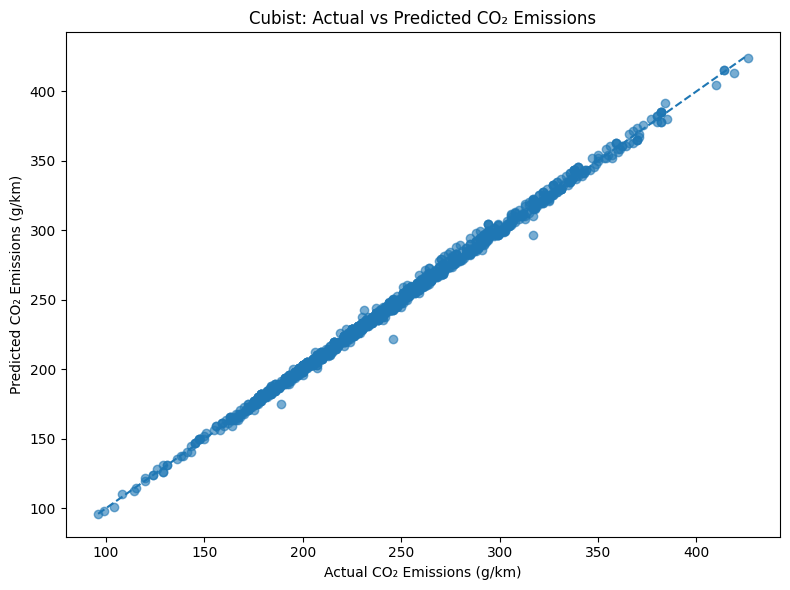

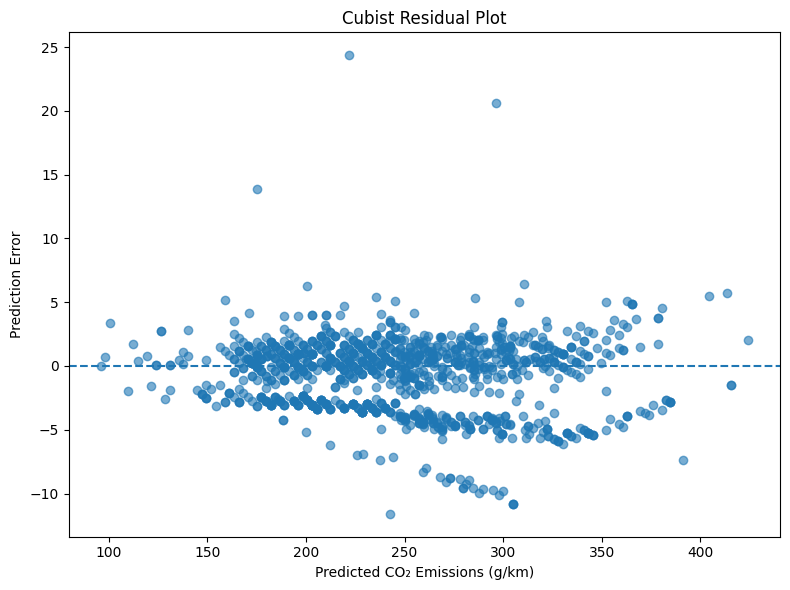

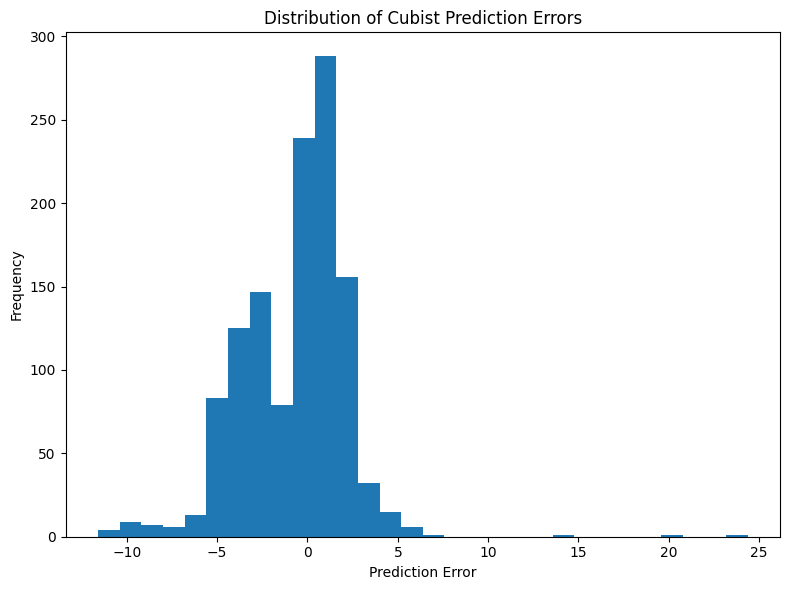


FINAL MODEL SUMMARY

Model: Cubist
Target: CO2 Emissions(g/km)

Validation:
  MAE: 2.1994
  RMSE: 3.0332
  R2: 0.9969

Test:
  MAE: 2.1778
  RMSE: 2.9894
  R2: 0.9971

Documentation files created:
  documentation/dataset_documentation.json
  documentation/model_documentation.json
  documentation/test_predictions.csv

Plots created:
  actual_vs_predicted.png
  residual_plot.png
  error_distribution.png


In [ ]:
# ============================================================
# CUBIST MODEL + DATASET DOCUMENTATION
# CO2 EMISSIONS PREDICTION
# ============================================================

# Install first:
# pip install cubist pandas numpy scikit-learn matplotlib seaborn

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from cubist import Cubist

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

DATA_FILE = "/content/co2_emission_final_encoded_dataset.csv"

df = pd.read_csv(DATA_FILE)

print("\nDataset loaded successfully")
print("-" * 60)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. DATASET DOCUMENTATION
# ============================================================

print("\n" + "=" * 60)
print("DATASET DOCUMENTATION")
print("=" * 60)

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


# ============================================================
# 3. TARGET VARIABLE
# ============================================================

TARGET = "CO2 Emissions(g/km)"
SPLIT = "Dataset"

print("\nTarget variable:")
print(TARGET)

print("\nTarget statistics:")
print(df[TARGET].describe())


# ============================================================
# 4. DATASET SPLIT
# ============================================================

print("\nDataset split:")

print(df[SPLIT].value_counts())

train_df = df[df[SPLIT] == "Train"].copy()
validation_df = df[df[SPLIT] == "Validation"].copy()
test_df = df[df[SPLIT] == "Test"].copy()

print("\nTraining samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Testing samples:", len(test_df))


# ============================================================
# 5. DEFINE FEATURES
# ============================================================

# Dataset column is not a predictive feature.
# Target column is also removed.

FEATURES = [
    column
    for column in df.columns
    if column not in [TARGET, SPLIT]
]

print("\nNumber of features:", len(FEATURES))

print("\nFeatures:")
for feature in FEATURES:
    print("-", feature)


# ============================================================
# 6. CREATE X AND y
# ============================================================

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_validation = validation_df[FEATURES]
y_validation = validation_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]


# ============================================================
# 7. TRAIN CUBIST MODEL
# ============================================================

print("\n" + "=" * 60)
print("TRAINING CUBIST MODEL")
print("=" * 60)

model = Cubist(
    n_rules=10,
    verbose=True
)

model.fit(
    X_train,
    y_train
)

print("\nModel training completed.")


# ============================================================
# 8. MODEL DOCUMENTATION
# ============================================================

print("\n" + "=" * 60)
print("MODEL DOCUMENTATION")
print("=" * 60)

print("\nModel:")
print(model)

print("\nModel parameters:")
print(model.get_params())


# ============================================================
# 9. VALIDATION PREDICTIONS
# ============================================================

validation_predictions = model.predict(X_validation)


# ============================================================
# 10. TEST PREDICTIONS
# ============================================================

test_predictions = model.predict(X_test)


# ============================================================
# 11. EVALUATION FUNCTION
# ============================================================

def evaluate_model(y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# ============================================================
# 12. VALIDATION PERFORMANCE
# ============================================================

validation_results = evaluate_model(
    y_validation,
    validation_predictions
)

print("\nValidation Performance")
print("-" * 40)

for metric, value in validation_results.items():
    print(f"{metric}: {value:.4f}")


# ============================================================
# 13. TEST PERFORMANCE
# ============================================================

test_results = evaluate_model(
    y_test,
    test_predictions
)

print("\nTest Performance")
print("-" * 40)

for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")


# ============================================================
# 14. ACTUAL VS PREDICTED
# ============================================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_predictions
})

results["Error"] = (
    results["Actual"] -
    results["Predicted"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

print("\nPrediction results:")
print(results.head(10))


# ============================================================
# 15. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    results["Actual"],
    results["Predicted"],
    alpha=0.6
)

minimum = min(
    results["Actual"].min(),
    results["Predicted"].min()
)

maximum = max(
    results["Actual"].max(),
    results["Predicted"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual CO₂ Emissions (g/km)")
plt.ylabel("Predicted CO₂ Emissions (g/km)")
plt.title("Cubist: Actual vs Predicted CO₂ Emissions")

plt.tight_layout()

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300
)

plt.show()


# ============================================================
# 16. RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    results["Predicted"],
    results["Error"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted CO₂ Emissions (g/km)")
plt.ylabel("Prediction Error")
plt.title("Cubist Residual Plot")

plt.tight_layout()

plt.savefig(
    "residual_plot.png",
    dpi=300
)

plt.show()


# ============================================================
# 17. ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    results["Error"],
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Cubist Prediction Errors")

plt.tight_layout()

plt.savefig(
    "error_distribution.png",
    dpi=300
)

plt.show()


# ============================================================
# 18. DATASET DOCUMENTATION FILE
# ============================================================

dataset_documentation = {

    "dataset_name":
        DATA_FILE,

    "number_of_rows":
        int(df.shape[0]),

    "number_of_columns":
        int(df.shape[1]),

    "target":
        TARGET,

    "number_of_features":
        len(FEATURES),

    "missing_values":
        int(df.isnull().sum().sum()),

    "duplicate_rows":
        int(df.duplicated().sum()),

    "splits": {
        "Train":
            int(len(train_df)),

        "Validation":
            int(len(validation_df)),

        "Test":
            int(len(test_df))
    },

    "features":
        FEATURES,

    "target_statistics": {

        "mean":
            float(df[TARGET].mean()),

        "std":
            float(df[TARGET].std()),

        "minimum":
            float(df[TARGET].min()),

        "maximum":
            float(df[TARGET].max()),

        "median":
            float(df[TARGET].median())
    }
}


# ============================================================
# 19. MODEL DOCUMENTATION FILE
# ============================================================

model_documentation = {

    "model_name":
        "Cubist",

    "model_type":
        "Rule-based piecewise linear regression",

    "library":
        "cubist",

    "repository":
        "https://github.com/pjaselin/Cubist",

    "task":
        "Regression",

    "target":
        TARGET,

    "number_of_rules":
        10,

    "number_of_features":
        len(FEATURES),

    "training_samples":
        len(train_df),

    "validation_samples":
        len(validation_df),

    "test_samples":
        len(test_df),

    "validation_metrics":
        validation_results,

    "test_metrics":
        test_results,

    "features":
        FEATURES
}


# ============================================================
# 20. SAVE DOCUMENTATION
# ============================================================

os.makedirs(
    "documentation",
    exist_ok=True
)


with open(
    "documentation/dataset_documentation.json",
    "w"
) as file:

    json.dump(
        dataset_documentation,
        file,
        indent=4
    )


with open(
    "documentation/model_documentation.json",
    "w"
) as file:

    json.dump(
        model_documentation,
        file,
        indent=4
    )


# ============================================================
# 21. SAVE PREDICTIONS
# ============================================================

results.to_csv(
    "documentation/test_predictions.csv",
    index=False
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print("\nModel: Cubist")
print("Target:", TARGET)

print("\nValidation:")
for metric, value in validation_results.items():
    print(f"  {metric}: {value:.4f}")

print("\nTest:")
for metric, value in test_results.items():
    print(f"  {metric}: {value:.4f}")

print("\nDocumentation files created:")

print(
    "  documentation/dataset_documentation.json"
)

print(
    "  documentation/model_documentation.json"
)

print(
    "  documentation/test_predictions.csv"
)

print("\nPlots created:")

print("  actual_vs_predicted.png")
print("  residual_plot.png")
print("  error_distribution.png")